In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print("HEALTHCARE ANALYTICS PROJECT - DATA EXPLORATION")
print("=" * 60)

HEALTHCARE ANALYTICS PROJECT - DATA EXPLORATION


In [2]:
# Load all CSV files
patients = pd.read_csv(r"C:\Users\Abhin\OneDrive\Documents\healthcare-analytics-portfolio\patients.csv")
doctors = pd.read_csv(r"C:\Users\Abhin\OneDrive\Documents\healthcare-analytics-portfolio\doctors.csv") 
appointments = pd.read_csv(r"C:\Users\Abhin\OneDrive\Documents\healthcare-analytics-portfolio\appointments.csv")
treatments = pd.read_csv(r"C:\Users\Abhin\OneDrive\Documents\healthcare-analytics-portfolio\treatments.csv")
billing = pd.read_csv(r"C:\Users\Abhin\OneDrive\Documents\healthcare-analytics-portfolio\billing.csv")

print("\nDATASET OVERVIEW")
print("-" * 30)

datasets = {
    'Patients': patients,
    'Doctors': doctors,
    'Appointments': appointments,
    'Treatments': treatments,
    'Billing': billing
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows × {df.shape[1]} columns")


DATASET OVERVIEW
------------------------------
Patients: 50 rows × 11 columns
Doctors: 10 rows × 8 columns
Appointments: 200 rows × 7 columns
Treatments: 200 rows × 6 columns
Billing: 200 rows × 7 columns


In [3]:
print("\nDETAILED DATASET EXAMINATION")
print("-" * 40)

for name, df in datasets.items():
    print(f"\n{name.upper()} DATASET:")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print("\nFirst few rows:")
    display(df.head(3))
    print("\nData types:")
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\n" + "="*50)


DETAILED DATASET EXAMINATION
----------------------------------------

PATIENTS DATASET:
Shape: (50, 11)
Columns: ['patient_id', 'first_name', 'last_name', 'gender', 'date_of_birth', 'contact_number', 'address', 'registration_date', 'insurance_provider', 'insurance_number', 'email']

First few rows:


,patient_id,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email
0,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com
1,P002,Emily,Smith,F,1984-10-12,8228188767,321 Maple Dr,2022-01-15,PulseSecure,INS354079,emily.smith@mail.com
2,P003,Laura,Jones,M,1977-08-21,8397029847,321 Maple Dr,2022-02-07,PulseSecure,INS650929,laura.jones@mail.com



Data types:
patient_id            object
first_name            object
last_name             object
gender                object
date_of_birth         object
contact_number         int64
address               object
registration_date     object
insurance_provider    object
insurance_number      object
email                 object
dtype: object

Missing values:
patient_id            0
first_name            0
last_name             0
gender                0
date_of_birth         0
contact_number        0
address               0
registration_date     0
insurance_provider    0
insurance_number      0
email                 0
dtype: int64


DOCTORS DATASET:
Shape: (10, 8)
Columns: ['doctor_id', 'first_name', 'last_name', 'specialization', 'phone_number', 'years_experience', 'hospital_branch', 'email']

First few rows:


,doctor_id,first_name,last_name,specialization,phone_number,years_experience,hospital_branch,email
0,D001,David,Taylor,Dermatology,8322010158,17,Westside Clinic,dr.david.taylor@hospital.com
1,D002,Jane,Davis,Pediatrics,9004382050,24,Eastside Clinic,dr.jane.davis@hospital.com
2,D003,Jane,Smith,Pediatrics,8737740598,19,Eastside Clinic,dr.jane.smith@hospital.com



Data types:
doctor_id           object
first_name          object
last_name           object
specialization      object
phone_number         int64
years_experience     int64
hospital_branch     object
email               object
dtype: object

Missing values:
doctor_id           0
first_name          0
last_name           0
specialization      0
phone_number        0
years_experience    0
hospital_branch     0
email               0
dtype: int64


APPOINTMENTS DATASET:
Shape: (200, 7)
Columns: ['appointment_id', 'patient_id', 'doctor_id', 'appointment_date', 'appointment_time', 'reason_for_visit', 'status']

First few rows:


...


Data types:
appointment_id      object
patient_id          object
doctor_id           object
appointment_date    object
appointment_time    object
reason_for_visit    object
status              object
dtype: object

Missing values:
appointment_id      0
patient_id          0
doctor_id           0
appointment_date    0
appointment_time    0
reason_for_visit    0
status              0
dtype: int64


TREATMENTS DATASET:
Shape: (200, 6)
Columns: ['treatment_id', 'appointment_id', 'treatment_type', 'description', 'cost', 'treatment_date']

First few rows:


,treatment_id,appointment_id,treatment_type,description,cost,treatment_date
0,T001,A001,Chemotherapy,Basic screening,3941.97,2023-08-09
1,T002,A002,MRI,Advanced protocol,4158.44,2023-06-09
2,T003,A003,MRI,Standard procedure,3731.55,2023-06-28



Data types:
treatment_id       object
appointment_id     object
treatment_type     object
description        object
cost              float64
treatment_date     object
dtype: object

Missing values:
treatment_id      0
appointment_id    0
treatment_type    0
description       0
cost              0
treatment_date    0
dtype: int64


BILLING DATASET:
Shape: (200, 7)
Columns: ['bill_id', 'patient_id', 'treatment_id', 'bill_date', 'amount', 'payment_method', 'payment_status']

First few rows:


,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status
0,B001,P034,T001,2023-08-09,3941.97,Insurance,Pending
1,B002,P032,T002,2023-06-09,4158.44,Insurance,Paid
2,B003,P048,T003,2023-06-28,3731.55,Insurance,Paid



Data types:
bill_id            object
patient_id         object
treatment_id       object
bill_date          object
amount            float64
payment_method     object
payment_status     object
dtype: object

Missing values:
bill_id           0
patient_id        0
treatment_id      0
bill_date         0
amount            0
payment_method    0
payment_status    0
dtype: int64



In [4]:
print("\nHEALTHCARE DATA QUALITY ASSESSMENT")
print("-" * 45)

# Check for data consistency issues
def assess_data_quality():
    issues = []
    
    # 1. Check for duplicate patient IDs
    if patients['patient_id'].duplicated().any():
        issues.append("ISSUE: Duplicate patient IDs found")
    else:
        issues.append("OK: No duplicate patient IDs")
    
    # 2. Check for duplicate doctor IDs
    if doctors['doctor_id'].duplicated().any():
        issues.append("ISSUE: Duplicate doctor IDs found")
    else:
        issues.append("OK: No duplicate doctor IDs")
    
    # 3. Check date formats
    try:
        pd.to_datetime(patients['date_of_birth'])
        issues.append("OK: Patient birth dates are valid")
    except:
        issues.append("ISSUE: Invalid date formats in patient birth dates")
    
    # 4. Check for reasonable age ranges
    try:
        patients['birth_date'] = pd.to_datetime(patients['date_of_birth'])
        patients['age'] = (datetime.now() - patients['birth_date']).dt.days / 365.25
        if (patients['age'] < 0).any() or (patients['age'] > 120).any():
            issues.append("ISSUE: Unreasonable ages detected")
        else:
            issues.append("OK: All patient ages are reasonable")
    except:
        issues.append("ISSUE: Could not calculate patient ages")
    
    # 5. Check billing amounts
    if (billing['amount'] < 0).any():
        issues.append("ISSUE: Negative billing amounts found")
    else:
        issues.append("OK: All billing amounts are positive")
    
    return issues

quality_issues = assess_data_quality()
for issue in quality_issues:
    print(issue)


HEALTHCARE DATA QUALITY ASSESSMENT
---------------------------------------------
OK: No duplicate patient IDs
OK: No duplicate doctor IDs
OK: Patient birth dates are valid
OK: All patient ages are reasonable
OK: All billing amounts are positive


In [5]:
print("\nKEY HEALTHCARE METRICS")
print("-" * 35)

# Patient Demographics
print("PATIENT DEMOGRAPHICS:")
if 'age' in patients.columns:
    print(f"• Average patient age: {patients['age'].mean():.1f} years")
    print(f"• Age range: {patients['age'].min():.0f} - {patients['age'].max():.0f} years")

if 'gender' in patients.columns:
    gender_dist = patients['gender'].value_counts()
    print(f"• Gender distribution:")
    for gender, count in gender_dist.items():
        print(f"  - {gender}: {count} ({count/len(patients)*100:.1f}%)")

# Financial Metrics
print(f"\nFINANCIAL OVERVIEW:")
print(f"• Total revenue: ${billing['amount'].sum():,.2f}")
print(f"• Average bill amount: ${billing['amount'].mean():.2f}")
print(f"• Revenue range: ${billing['amount'].min():.2f} - ${billing['amount'].max():.2f}")

# Treatment costs vs billing amounts (data integrity check)
treatment_revenue = treatments['cost'].sum()
billing_revenue = billing['amount'].sum()
print(f"• Treatment costs total: ${treatment_revenue:,.2f}")
print(f"• Billing revenue total: ${billing_revenue:,.2f}")
print(f"• Revenue difference: ${abs(treatment_revenue - billing_revenue):,.2f}")

# Doctor Specializations
print(f"\nDOCTOR SPECIALIZATIONS:")
spec_dist = doctors['specialization'].value_counts()
for spec, count in spec_dist.items():
    print(f"• {spec}: {count} doctors")

# Appointment Status
print(f"\nAPPOINTMENT STATUS:")
status_dist = appointments['status'].value_counts()
for status, count in status_dist.items():
    print(f"• {status}: {count} ({count/len(appointments)*100:.1f}%)")


KEY HEALTHCARE METRICS
-----------------------------------
PATIENT DEMOGRAPHICS:
• Average patient age: 45.2 years
• Age range: 20 - 76 years
• Gender distribution:
  - M: 31 (62.0%)
  - F: 19 (38.0%)

FINANCIAL OVERVIEW:
• Total revenue: $551,249.85
• Average bill amount: $2756.25
• Revenue range: $534.03 - $4973.63
• Treatment costs total: $551,249.85
• Billing revenue total: $551,249.85
• Revenue difference: $0.00

DOCTOR SPECIALIZATIONS:
• Pediatrics: 5 doctors
• Dermatology: 3 doctors
• Oncology: 2 doctors

APPOINTMENT STATUS:
• No-show: 52 (26.0%)
• Scheduled: 51 (25.5%)
• Cancelled: 51 (25.5%)
• Completed: 46 (23.0%)


In [6]:
print("\nTEMPORAL DATA PREPARATION")
print("-" * 35)

# Convert date columns
try:
    appointments['appointment_datetime'] = pd.to_datetime(
        appointments['appointment_date'] + ' ' + appointments['appointment_time']
    )
    appointments['appointment_date_clean'] = pd.to_datetime(appointments['appointment_date'])
    
    treatments['treatment_date_clean'] = pd.to_datetime(treatments['treatment_date'])
    billing['bill_date_clean'] = pd.to_datetime(billing['bill_date'])
    patients['registration_date_clean'] = pd.to_datetime(patients['registration_date'])
    
    print("SUCCESS: Successfully converted date columns")
    
    # Date ranges
    print(f"\nDATE RANGES:")
    print(f"• Appointments: {appointments['appointment_date_clean'].min()} to {appointments['appointment_date_clean'].max()}")
    print(f"• Treatments: {treatments['treatment_date_clean'].min()} to {treatments['treatment_date_clean'].max()}")
    print(f"• Patient registrations: {patients['registration_date_clean'].min()} to {patients['registration_date_clean'].max()}")
    
except Exception as e:
    print(f"ERROR: Date conversion issues: {e}")


TEMPORAL DATA PREPARATION
-----------------------------------
SUCCESS: Successfully converted date columns

DATE RANGES:
• Appointments: 2023-01-01 00:00:00 to 2023-12-30 00:00:00
• Treatments: 2023-01-01 00:00:00 to 2023-12-30 00:00:00
• Patient registrations: 2021-01-23 00:00:00 to 2023-12-12 00:00:00


In [7]:
print("\nDATASET RELATIONSHIPS")
print("-" * 30)

# Check referential integrity
def check_relationships():
    relationships = []
    
    # Patients in appointments
    patients_in_appt = set(appointments['patient_id'].unique())
    all_patients = set(patients['patient_id'].unique())
    relationships.append(f"• Patients with appointments: {len(patients_in_appt)}/{len(all_patients)}")
    
    # Doctors in appointments  
    doctors_in_appt = set(appointments['doctor_id'].unique())
    all_doctors = set(doctors['doctor_id'].unique())
    relationships.append(f"• Doctors with appointments: {len(doctors_in_appt)}/{len(all_doctors)}")
    
    # Appointments with treatments
    appt_with_treatment = set(treatments['appointment_id'].unique())
    all_appointments = set(appointments['appointment_id'].unique())
    relationships.append(f"• Appointments with treatments: {len(appt_with_treatment)}/{len(all_appointments)}")
    
    # Treatments with billing
    treatments_billed = set(billing['treatment_id'].unique())
    all_treatments = set(treatments['treatment_id'].unique())
    relationships.append(f"• Treatments with billing: {len(treatments_billed)}/{len(all_treatments)}")
    
    return relationships

relationship_stats = check_relationships()
for stat in relationship_stats:
    print(stat)


DATASET RELATIONSHIPS
------------------------------
• Patients with appointments: 48/50
• Doctors with appointments: 10/10
• Appointments with treatments: 200/200
• Treatments with billing: 200/200



CREATING INITIAL VISUALIZATIONS
----------------------------------------


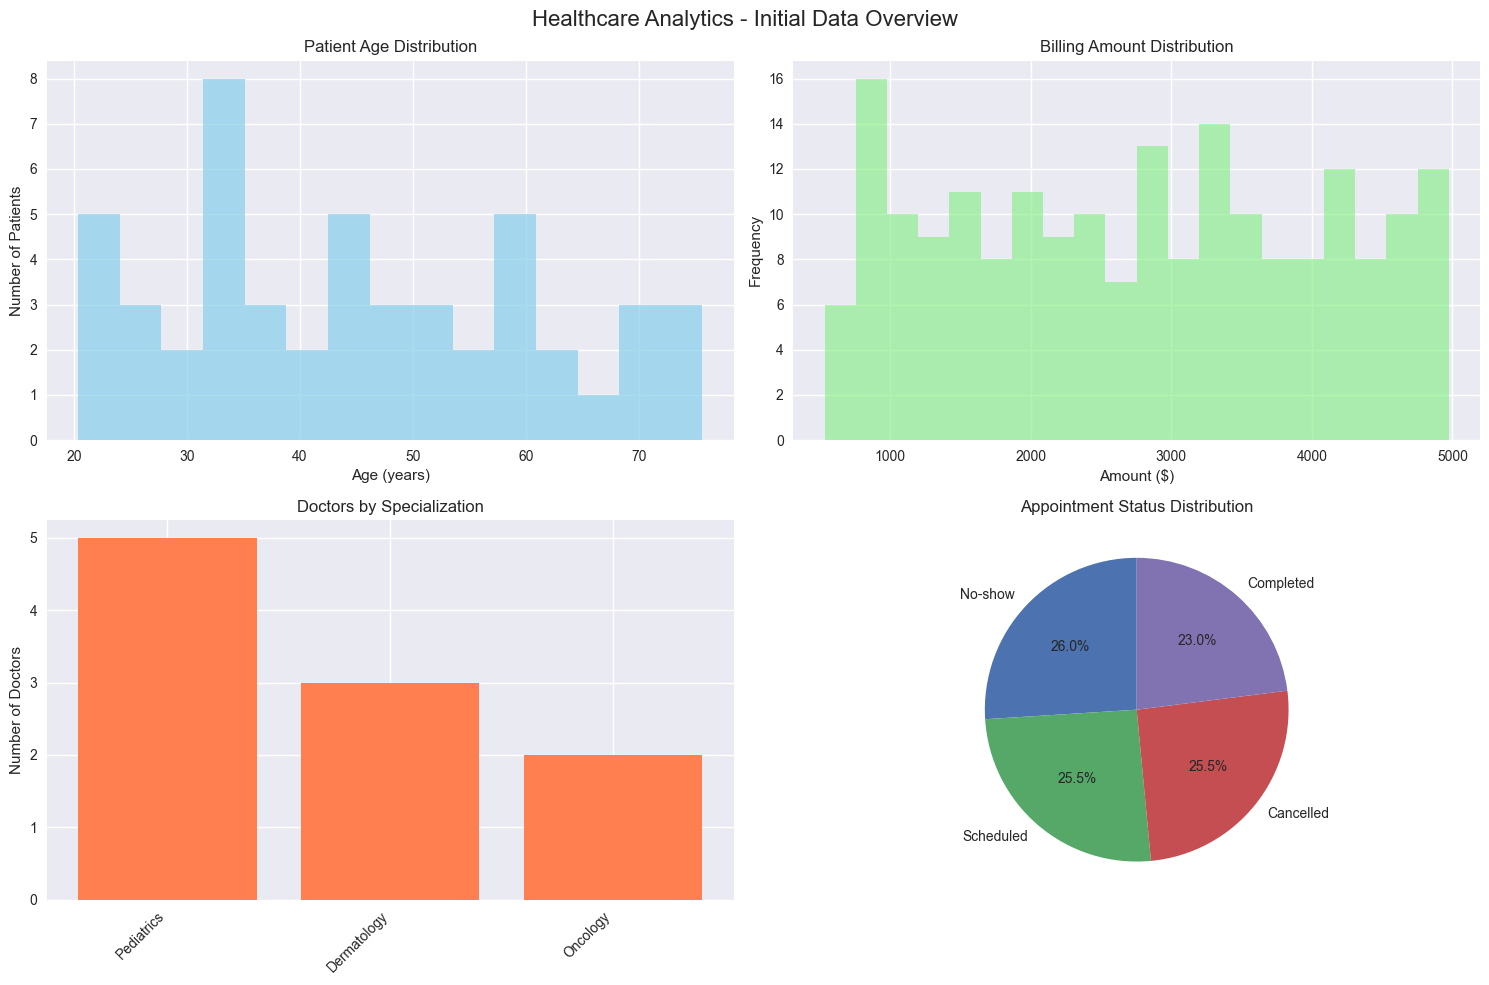

In [8]:
print("\nCREATING INITIAL VISUALIZATIONS")
print("-" * 40)

# Set up subplot figure
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Healthcare Analytics - Initial Data Overview', fontsize=16)

# 1. Patient Age Distribution
if 'age' in patients.columns:
    axes[0,0].hist(patients['age'], bins=15, alpha=0.7, color='skyblue')
    axes[0,0].set_title('Patient Age Distribution')
    axes[0,0].set_xlabel('Age (years)')
    axes[0,0].set_ylabel('Number of Patients')

# 2. Revenue Distribution
axes[0,1].hist(billing['amount'], bins=20, alpha=0.7, color='lightgreen')
axes[0,1].set_title('Billing Amount Distribution')
axes[0,1].set_xlabel('Amount ($)')
axes[0,1].set_ylabel('Frequency')

# 3. Doctor Specializations
spec_counts = doctors['specialization'].value_counts()
axes[1,0].bar(range(len(spec_counts)), spec_counts.values, color='coral')
axes[1,0].set_title('Doctors by Specialization')
axes[1,0].set_xticks(range(len(spec_counts)))
axes[1,0].set_xticklabels(spec_counts.index, rotation=45, ha='right')
axes[1,0].set_ylabel('Number of Doctors')

# 4. Appointment Status
status_counts = appointments['status'].value_counts()
axes[1,1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Appointment Status Distribution')

plt.tight_layout()
plt.show()
